In [7]:
import sys, os
import sqlite3
import pandas as pd
from dotenv import load_dotenv
load_dotenv()
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_csv, load_sqlite, load_postgres, save_to_sqlite, create_engine

df = load_csv('../data/Walmart.csv')
# print("CSV preview:")
# print(df.head())

# --- Load SQLite ---
# Connect/create SQLite DB
conn = sqlite3.connect('../data/walmart.db')

# Save DataFrame as a table
save_to_sqlite(df)

# Test reading
df_postgres = pd.read_sql("SELECT * FROM sales LIMIT 5;", conn)
#print(df_postgres.head())
    
conn.close()

# --- Load PostgreSQL (if available) ---
# Replace with your own engine URL
engine_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
df_pg = load_postgres("SELECT * FROM sales LIMIT 5;", engine_url)
print("PostgreSQL preview:")
print(df_pg.head())

PostgreSQL preview:
   store        date  weekly_sales  holiday_flag  temperature  fuel_price  \
0      1  2010-02-05    1643690.90         False        42.31        2.57   
1      1  2010-02-12    1641957.44          True        38.51        2.55   
2      1  2010-02-19    1611968.17         False        39.93        2.51   
3      1  2010-02-26    1409727.59         False        46.63        2.56   
4      1  2010-03-05    1554806.68         False        46.50        2.63   

       cpi  unemployment  
0  211.096         8.106  
1  211.242         8.106  
2  211.289         8.106  
3  211.320         8.106  
4  211.350         8.106  


#### Do holidays have higher sales?

In [35]:
query = """
SELECT 
    holiday_flag, 
    AVG(weekly_sales) AS avg_weekly_sales
FROM sales
GROUP BY  holiday_flag
ORDER BY avg_weekly_sales DESC;
"""
df_result1 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result1)
print(df_result1['avg_weekly_sales'][0]-df_result1['avg_weekly_sales'][1])

Query result preview:
   holiday_flag  avg_weekly_sales
0          True      1.122888e+06
1         False      1.041256e+06
81631.51214670017


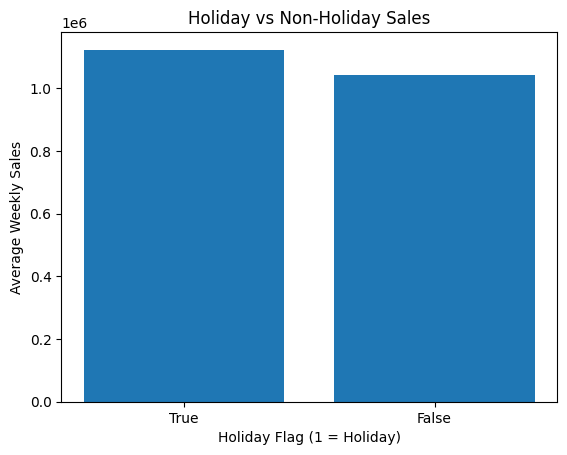

In [33]:
import matplotlib.pyplot as plt, numpy as np

plt.bar(df_result1['holiday_flag'].astype(str), df_result1['avg_weekly_sales'])
plt.xlabel("Holiday Flag (1 = Holiday)")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

#### Does the effect vary by store?

In [36]:
query = """
SELECT 
    store, 
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) AS avg_holiday_sales,
    AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS avg_non_holiday_sales,
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) - AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS sales_diff
FROM sales
GROUP BY store
ORDER BY sales_diff DESC;
"""
df_result = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result)

Query result preview:
    store  avg_holiday_sales  avg_non_holiday_sales     sales_diff
0      10        2113755.949           1.883309e+06  230446.517421
1      28        1478244.605           1.311889e+06  166355.623571
2      35        1074348.457           9.080992e+05  166249.302789
3       2        2079266.900           1.914209e+06  165058.088120
4       4        2243102.624           2.083556e+06  159546.780842
5      20        2249035.081           2.097048e+06  151986.647541
6      19        1577046.734           1.435071e+06  141976.096707
7      12        1138140.420           9.992919e+05  138848.495564
8      24        1475098.251           1.347857e+06  127240.816639
9      27        1892299.278           1.766413e+06  125886.314842
10      6        1680907.927           1.555993e+06  124915.059556
11      1        1665747.656           1.546957e+06  118790.270361
12     13        2113043.806           1.995393e+06  117650.830511
13     31        1500026.030           1

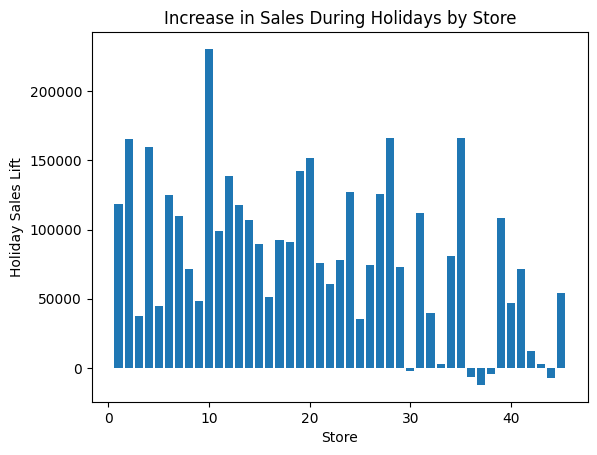

In [30]:
plt.bar(df_result['store'], df_result['sales_diff'])
plt.xlabel("Store")
plt.ylabel("Holiday Sales Lift")
plt.title("Increase in Sales During Holidays by Store")
plt.show()

Some stores have very high differences between holiday-week sales and non-holiday-week sales, but almost all stores have a increase in sales on holidays. 

#### Which stores generate the most sales?

In [39]:
query = """
SELECT 
    store, 
    SUM(weekly_sales) AS total_weekly_sales
FROM sales
GROUP BY store
ORDER BY total_weekly_sales DESC;
"""
df_result3 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result3.head())

Query result preview:
   store  total_weekly_sales
0     20        6.027956e+08
1      4        5.990879e+08
2     14        5.779998e+08
3     13        5.730354e+08
4      2        5.507649e+08


Stores 20, 4, 14, 13, and 2 are the highest earning stores out of the 45 Walmart stores in the dataset.

#### Do factors such as temperature, fuel price, or consumer price index (CPI) correlate with weekly sales?

In [54]:
query = """
SELECT 
    CORR(weekly_sales, temperature) AS temp_corr,
    CORR(weekly_sales, fuel_price) AS fuel_corr,
    CORR(weekly_sales, unemployment) AS unemployment_corr,
    CORR(weekly_sales, cpi) AS cpi_corr
FROM sales;
"""
df_result4 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result4.head())

Query result preview:
   temp_corr  fuel_corr  unemployment_corr  cpi_corr
0   -0.06381   0.009483          -0.106176 -0.072634


Overall, since the correlation coefficients are near 0, temperature, fuel price, and consumer price index has little effect on weekly sales.  
However, perhaps it depends on the store.

In [57]:
query = """
SELECT 
    store, 
    CORR(weekly_sales, temperature) AS temp_corr,
    CORR(weekly_sales, fuel_price) AS fuel_corr,
    CORR(weekly_sales, unemployment) AS unemployment_corr,
    CORR(weekly_sales, cpi) AS cpi_corr
FROM sales
GROUP BY store;
"""
df_result5 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result5.head())

Query result preview:
   store  temp_corr  fuel_corr  unemployment_corr  cpi_corr
0     42  -0.151639   0.322004          -0.356355  0.360889
1     29  -0.129144  -0.091822           0.084682 -0.072529
2      4  -0.225583   0.211368          -0.337015  0.351163
3     34  -0.278523   0.013904           0.017010  0.115442
4     41   0.106761   0.304837          -0.350630  0.392278


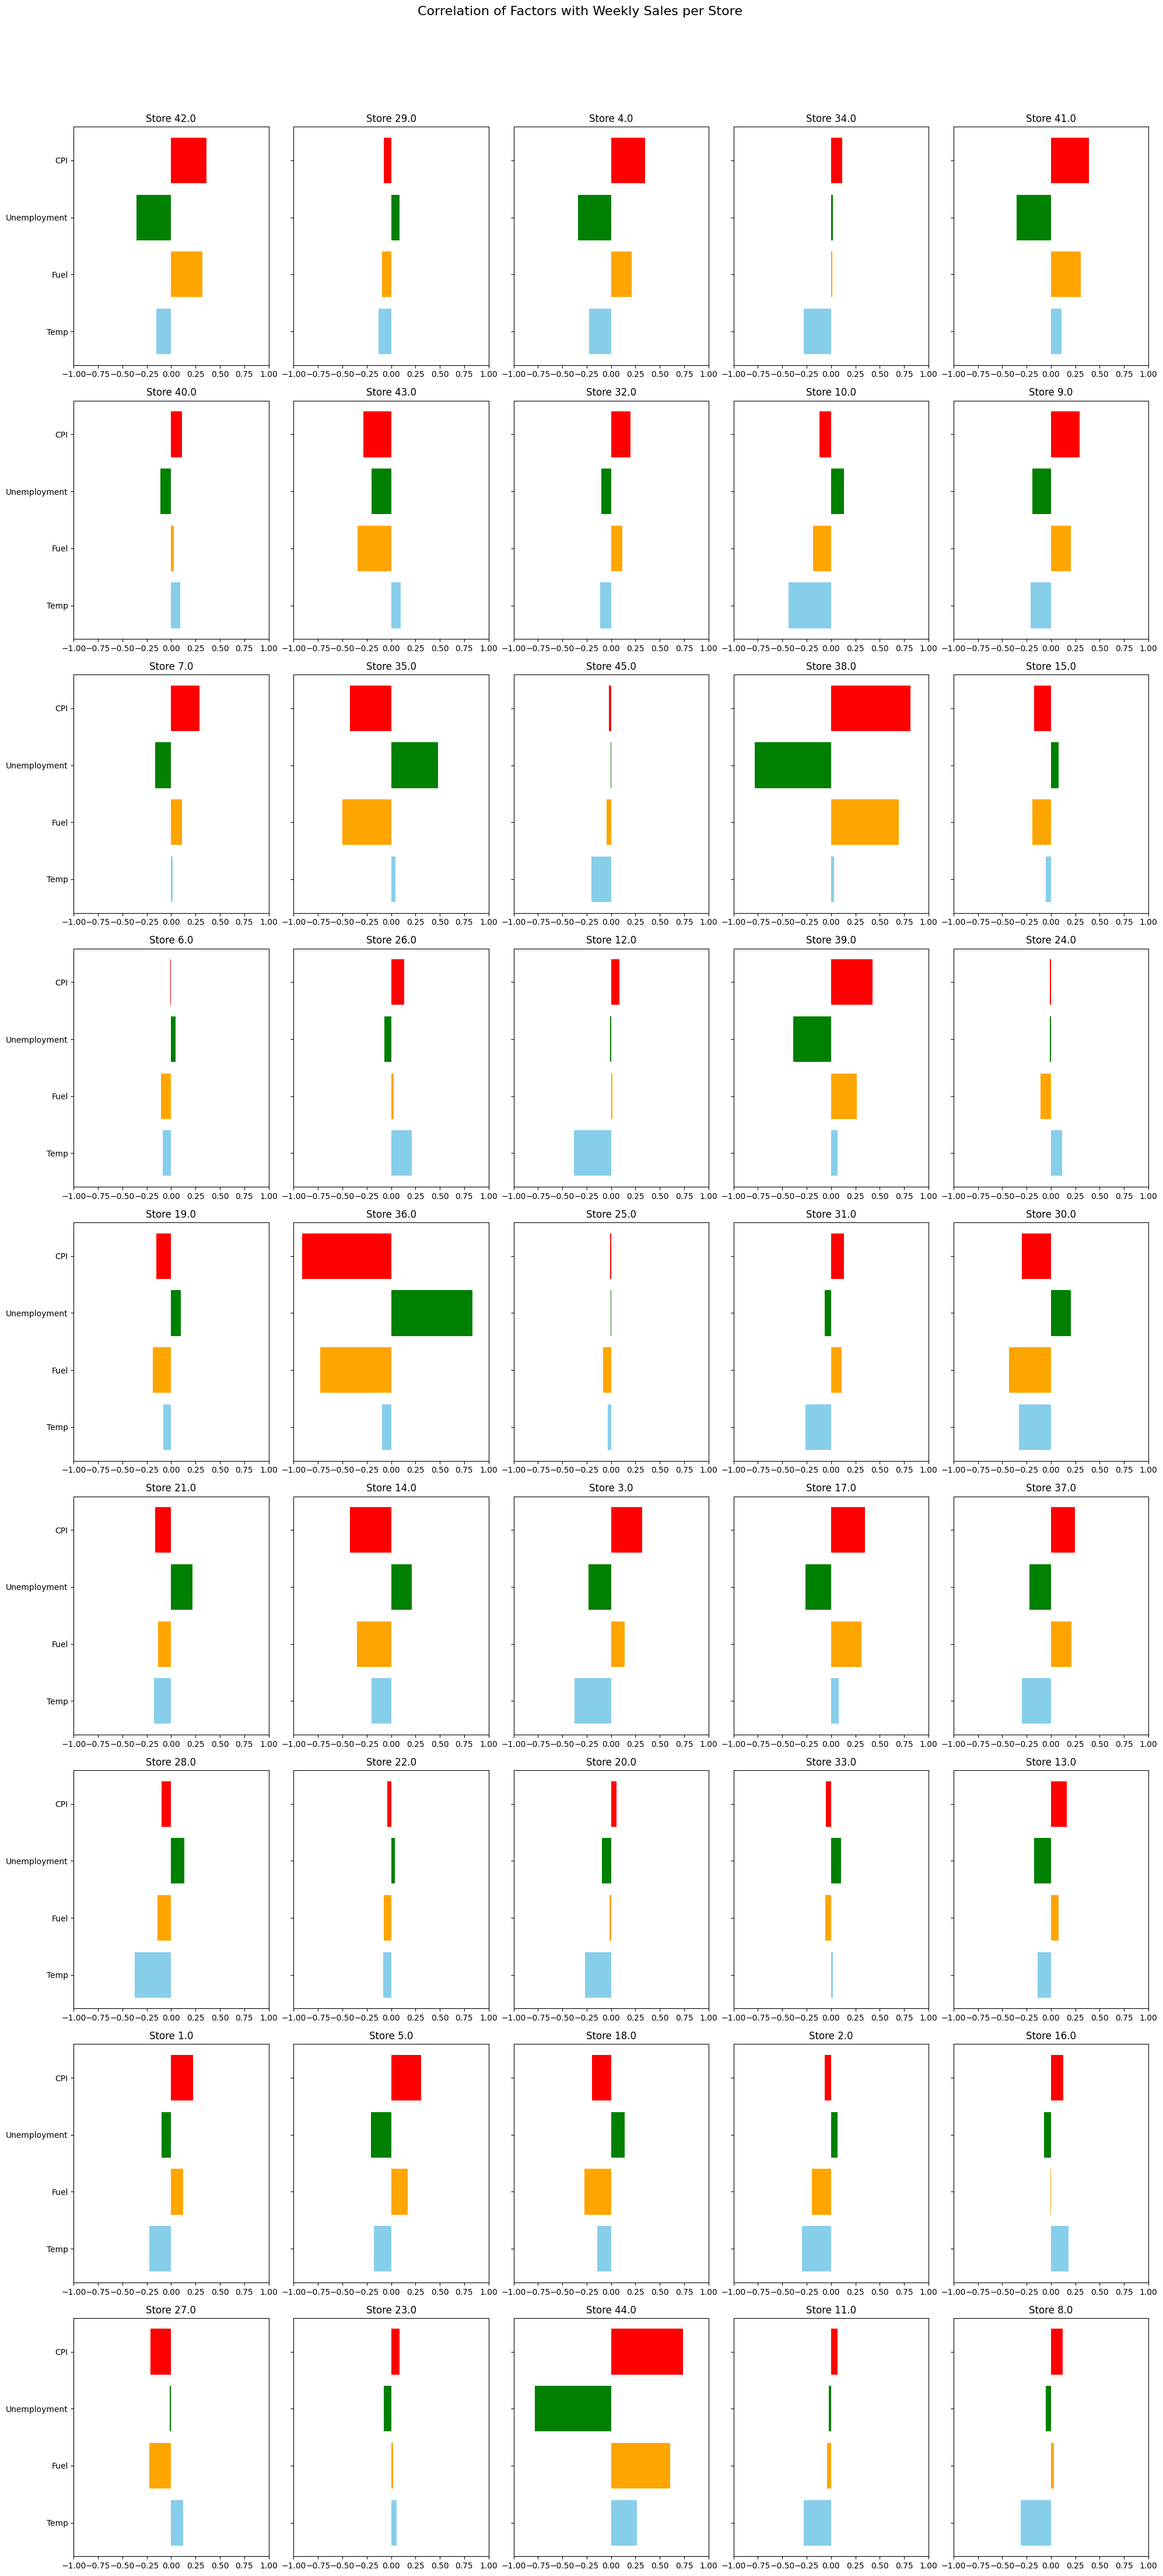

In [60]:
import math
df = df_result5  # your query result
factors = ['Temp', 'Fuel', 'Unemployment', 'CPI']

num_stores = len(df)
cols = 5  # number of charts per row
rows = math.ceil(num_stores / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 5*rows), sharey=True)
axes = axes.flatten()  # flatten in case rows*cols > num_stores

for ax, (_, row) in zip(axes, df.iterrows()):
    values = [row['temp_corr'], row['fuel_corr'], row['unemployment_corr'], row['cpi_corr']]
    ax.barh(factors, values, color=['skyblue', 'orange', 'green', 'red'])
    ax.set_xlim(-1, 1)
    ax.set_title(f'Store {row["store"]}')

# Hide any extra axes if num_stores < rows*cols
for ax in axes[num_stores:]:
    ax.axis('off')

fig.suptitle('Correlation of Factors with Weekly Sales per Store', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

From analysis store-level correlations between weekly sales and temperature, unemployment, fuel, and CPI, some stores have stronger correlations between weekly sales and these external factors. This can be useful when training a predictive or forecasting model on sales, and can guide inventory management with the predicted number of weekly sales using these external factors as a predictive indicator.

#### Which stores are more consistent vs more volatile?

In [65]:
query6 = """
SELECT 
    store,
    STDDEV(weekly_sales) AS sales_stddev
FROM sales
GROUP BY store
ORDER BY sales_stddev DESC;
"""
df_result6 = load_postgres(query6, engine_url)
print("Most volatile stores:")
print(df_result6.head())#Most volatile stores based on standard deviation of weekly sales
print("Least volatile stores:")
print(df_result6.tail())#Least volatile stores based on standard deviation of weekly sales

Most volatile stores:
   store   sales_stddev
0     14  317012.319634
1     10  301731.312205
2     20  275416.101328
3      4  265734.011836
4     13  265040.784712
Least volatile stores:
    store  sales_stddev
40      5  37671.700609
41     44  24719.350275
42     33  24090.551649
43     30  22769.613469
44     37  21799.116189


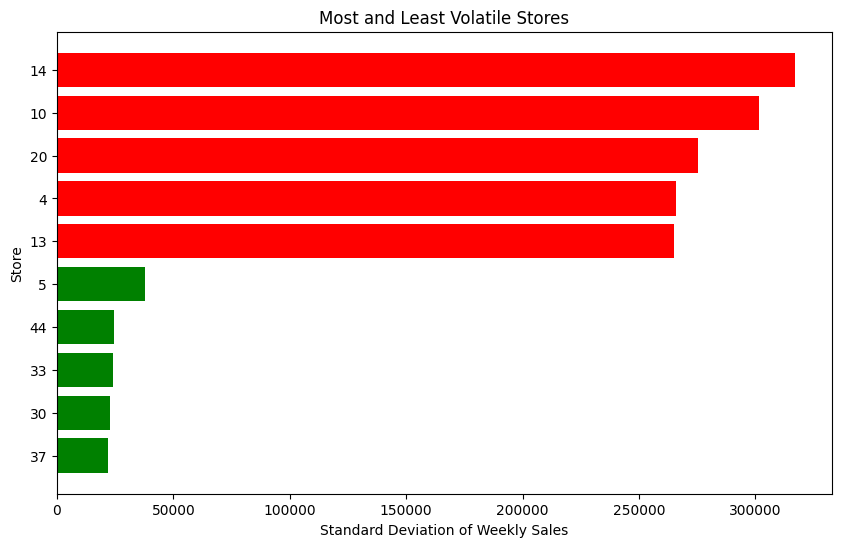

In [66]:
# Sort by volatility
df_sorted = df_result6.sort_values('sales_stddev', ascending=False)

# Pick top 5 most volatile and bottom 5 least volatile
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)

# Combine for plotting
df_plot = pd.concat([top_5, bottom_5])

# Create a horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(df_plot['store'].astype(str), df_plot['sales_stddev'], color=['red']*5 + ['green']*5)
plt.xlabel('Standard Deviation of Weekly Sales')
plt.ylabel('Store')
plt.title('Most and Least Volatile Stores')
plt.gca().invert_yaxis()  # optional: largest value on top
plt.show()